In [19]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style = "whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [20]:
df = pd.read_csv('C:/Users/Daniel/IT/PetPr/salary_prediction/data/ds_salaries.csv')
display(df.head())

print('DATASET INFO')
df.info()

display(df.describe())

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 73.8 KB


,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [22]:
mis_per = (df.isnull().sum()/len(df))*100
mis_df = pd.DataFrame({'пропуски': df.isnull().sum(), 'пропуски в проц': mis_per})
display(mis_df[mis_df['пропуски'] > 0].sort_values(by='пропуски в проц', ascending=False))

,пропуски,пропуски в проц


Хороший датасет подобрали - чудненько, что нету пропусков. 
(в этом и был план, если че)

C:\Users\Daniel\AppData\Local\Temp\ipykernel_8628\1903137033.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Daniel\AppData\Local\Temp\ipykernel_8628\1903137033.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


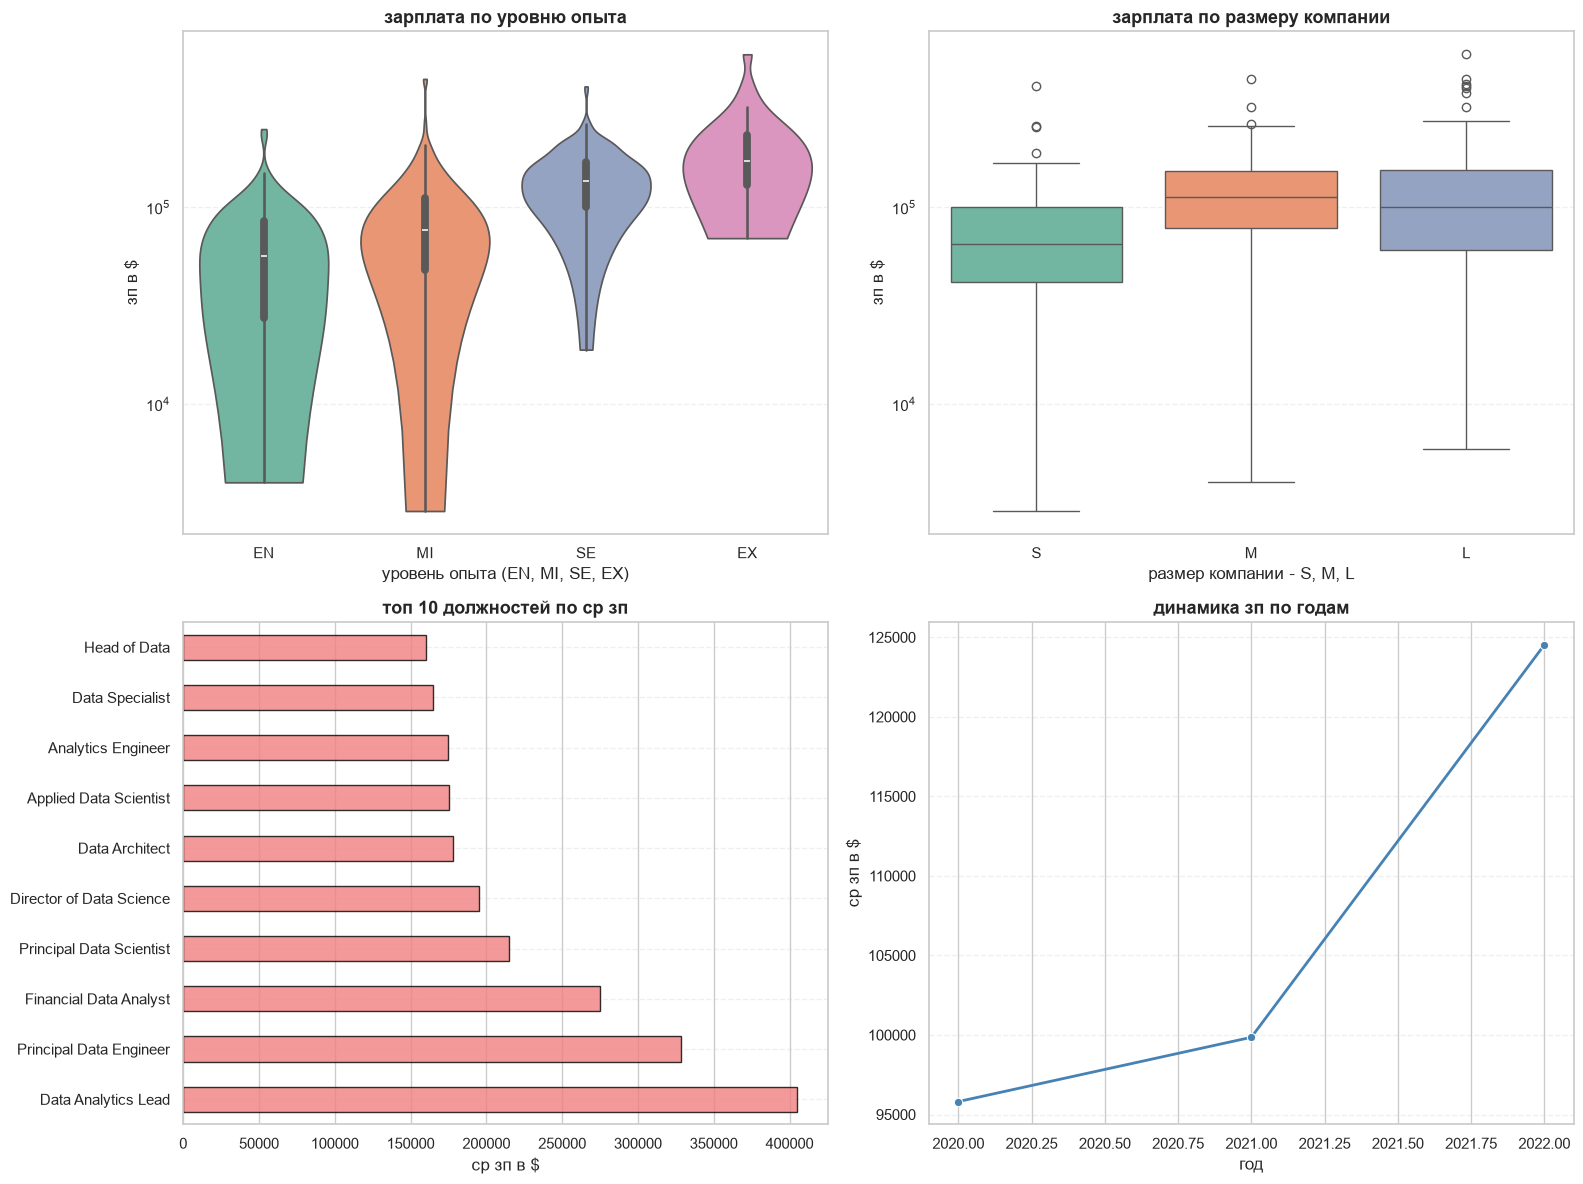

In [47]:
# разметка
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax in axes.flatten():
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# зарплата от уровня опыта 
experience_order = ['EN', 'MI', 'SE', 'EX']
sns.violinplot(
    data=df, 
    x='experience_level', 
    y='salary_in_usd', 
    order=experience_order,
    ax=axes[0, 0],
    palette='Set2',
    inner='box', 
    cut=0 
)
axes[0, 0].set_title('зарплата по уровню опыта', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('уровень опыта (EN, MI, SE, EX)')
axes[0, 0].set_ylabel('зп в $')
axes[0, 0].set_yscale('log')
# зарплата от размера компании
company_order = ['S', 'M', 'L']
sns.boxplot(
    data=df, 
    x='company_size', 
    y='salary_in_usd', 
    order=company_order,
    ax=axes[0, 1],
    palette='Set2'
)
axes[0, 1].set_title('зарплата по размеру компании', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('размер компании - S, M, L')
axes[0, 1].set_ylabel('зп в $')
axes[0, 1].set_yscale('log')

# топ должностей по зп
top_jobs = df.groupby('job_title')['salary_in_usd'].mean().nlargest(10)
top_jobs.plot(kind='barh', ax=axes[1, 0], color='lightcoral', edgecolor='black', alpha=0.8)
axes[1, 0].set_title('топ 10 должностей по ср зп', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('ср зп в $')
axes[1, 0].set_ylabel('')

# динамика зп по годам
sns.lineplot(
    data=df, 
    x='work_year', 
    y='salary_in_usd', 
    ax=axes[1, 1],
    marker='o', 
    errorbar=None, 
    color='steelblue',
    linewidth=2
)
axes[1, 1].set_title('динамика зп по годам', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('год')
axes[1, 1].set_ylabel('ср зп в $')


plt.tight_layout()
plt.show()

Исходя из этих графиков имеем:
1) Опыт, конеч важен очень, но не всегда. Логично, что чем больше стаж, тем выше у человека доход. Экзекьютивы в среднем получают около 150к, что аж в три раза больше джунов с примерно 50к (интересный датасет, кнч, чтобы у джунов в год было 50к бачей...). Но вот у мидлов разброс в доходах огромный. Короче, дело не только в опыте. Мб на собесах по факту решают и другие факторы.
2) Масштаб не прям важная штука. Корреляция есть, конечно, но не решающая. Видно, что в крупных компаниях платят несколько больше, чем в малых, но вот если сравнивать большие компании со средними, то разница не так очевидна.
3) В топе по доходам имеем всяких разных эксклюзиных личностей (лидов, директоров и проч). Можно потом будет рассмотреть полезность этой корелляции. обычный дата аналитик в этот топ 3 не попал.
4) Ну для интереса - зп идут вверх. С 2020 по 2022 год средний доход в индустрии увеличился. Тенденцию видно с 95к до 125к (на треть!). 
Короче говоря, обучая модель, нужно делать главный упор на экспириенс и должность — но их лучше сначала объединить в группы по смыслу — и размер компании.